# Chronos-2 foundation model: unrestricted 72 h versus manual 42 h

This notebook applies the same leakage-safe experiment used by the classical, LSTM, and TCN notebooks to Amazon's **120M-parameter Chronos-2** foundation model (`amazon/chronos-2`). Chronos-2 natively supports past-only covariates and probabilistic zero-shot forecasting; see the [official repository](https://github.com/amazon-science/chronos-forecasting), [quick-start notebook](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb), and [technical report](https://arxiv.org/abs/2510.15821).

The matched representations are:

- **Unrestricted 72 h:** Indusii is the target; the previous 288 rows of Terneuzen, Westdorpe, Gent-far, and Gent-near are past covariates.
- **Manual 42 h:** Indusii is the target; its one- and two-hour changes and Terneuzen shifted by exactly 42 hours are past covariates over 168 rows. This is the same sequence representation used for LSTM/TCN.
- **Validation:** every valid August 2025 forecast origin, used only to fit conservative residual-shrinkage weights.
- **Test:** every valid September 2025 origin, untouched until final scoring.
- **Forecast:** all 16 quarter-hour values in the next four hours.

Chronos-2 remains **zero-shot**: no model weights are trained on this canal dataset. Results are shown both raw and after the same August-only calibration used in the other comparison notebooks. Persistence is evaluated at every lead, at the four-hour endpoint, and on the largest 10% of target changes.

In [1]:
from pathlib import Path
import os, sys, time

ROOT = Path.cwd().resolve()
if not (ROOT / "lag_analytics_workspace").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from chronos import BaseChronosPipeline, Chronos2Pipeline

from time_series_analysis.paper_experiment_utils import (
    FORECAST_STEPS,
    build_neural_datasets,
    evaluation_rows,
    load_prepared_observations,
    split_shape_table,
    validation_calibration,
)

MODEL_ID = "amazon/chronos-2"
DEVICE = "cpu"
BATCH_SIZE = 128
torch.set_num_threads(min(8, os.cpu_count() or 1))
pd.set_option("display.max_columns", 30)
print("Chronos package and PyTorch:", __import__("chronos").__version__, torch.__version__)
print("Device:", DEVICE)

C:\gtc-chronos\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chronos package and PyTorch: 2.3.1 2.13.0+cpu
Device: cpu


## 1. Reuse the paper's prepared data and matched origins

The shared repository utility reads QUDT-normalized values from Fuseki, applies causal trailing two-hour smoothing, restricts interpolation to short internal gaps, and creates identical valid origins for both representations. Chronos receives the reconstructed raw physical values; its own per-series normalization remains responsible for foundation-model scaling.

In [2]:
data, coverage, unit_report = load_prepared_observations()
datasets = build_neural_datasets(data)
display(coverage)
display(split_shape_table(datasets))

,first observation,last observation,missing after preparation,minimum mS/cm,maximum mS/cm
sensor,,,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372,0.108207,2.339817
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257,0.107912,3.997718
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254,0.055390,1.882214
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253,0.068467,1.792810
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962,0.000018,1.945475


,Representation,Split,X shape,y shape,First forecast,Last forecast
0,unrestricted_72h,train,"(3990, 288, 5)","(3990, 16)",2025-01-04 17:45:00+00:00,2025-07-31 23:45:00+00:00
1,unrestricted_72h,validation,"(2469, 288, 5)","(2469, 16)",2025-08-01 03:45:00+00:00,2025-08-31 23:45:00+00:00
2,unrestricted_72h,test,"(2865, 288, 5)","(2865, 16)",2025-09-01 03:45:00+00:00,2025-09-30 23:45:00+00:00
3,manual_42h,train,"(3990, 168, 4)","(3990, 16)",2025-01-04 17:45:00+00:00,2025-07-31 23:45:00+00:00
4,manual_42h,validation,"(2469, 168, 4)","(2469, 16)",2025-08-01 03:45:00+00:00,2025-08-31 23:45:00+00:00
5,manual_42h,test,"(2865, 168, 4)","(2865, 16)",2025-09-01 03:45:00+00:00,2025-09-30 23:45:00+00:00


In [3]:
def reconstruct_raw_sequences(dataset, split_name):
    split = dataset.splits[split_name]
    n_samples, n_steps, n_features = split.X.shape
    raw = dataset.input_scaler.inverse_transform(split.X.reshape(-1, n_features))
    return raw.reshape(n_samples, n_steps, n_features).astype(np.float32)


SCHEMAS = {
    "unrestricted_72h": {
        "target": "Indusii",
        "covariates": ["Terneuzen", "Westdorpe", "Gent - far", "Gent - near"],
    },
    "manual_42h": {
        "target": "current_target",
        "covariates": ["target_change_1h", "target_change_2h", "terneuzen_lag_42h"],
    },
}


def chronos_inputs(dataset, split_name):
    raw = reconstruct_raw_sequences(dataset, split_name)
    feature_index = {name: i for i, name in enumerate(dataset.feature_names)}
    schema = SCHEMAS[dataset.name]
    target_index = feature_index[schema["target"]]
    return [
        {
            "target": sequence[:, target_index],
            "past_covariates": {
                name: sequence[:, feature_index[name]] for name in schema["covariates"]
            },
        }
        for sequence in raw
    ]


for name, dataset in datasets.items():
    example = chronos_inputs(dataset, "validation")[0]
    print(name, "target", example["target"].shape, "covariates", list(example["past_covariates"]))

unrestricted_72h target (288,) covariates ['Terneuzen', 'Westdorpe', 'Gent - far', 'Gent - near']
manual_42h target (168,) covariates ['target_change_1h', 'target_change_2h', 'terneuzen_lag_42h']


## 2. Load the official foundation model

On native Windows, current PyTorch uses CPU for this setup. Set `CHRONOS_LOCAL_FILES_ONLY=1` to force an already-cached model; otherwise the official Hugging Face weights are downloaded on first use. Float32 avoids unsupported reduced-precision CPU operations.

In [4]:
started = time.perf_counter()
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.float32,
    local_files_only=os.getenv("CHRONOS_LOCAL_FILES_ONLY", "0") == "1",
)
print(f"Loaded {MODEL_ID} in {time.perf_counter() - started:.1f}s")
print(f"Parameters: {sum(p.numel() for p in pipeline.model.parameters()):,}")
print("Native quantiles:", pipeline.quantiles)

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 5412.79it/s]

Loaded amazon/chronos-2 in 0.2s
Parameters: 119,477,664
Native quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]


## 3. Dense zero-shot inference and August-only calibration

The model produces 21 native quantiles. The 0.5 quantile is the point forecast. For direct comparability, one residual multiplier per lead is fitted on August and constrained to `[0, 1]`; this can only shrink Chronos-2 toward persistence. Raw zero-shot results remain in the final table so the calibration effect is transparent.

In [5]:
median_index = pipeline.quantiles.index(0.5)
q10_index = pipeline.quantiles.index(0.1)
q90_index = pipeline.quantiles.index(0.9)


def predict_quantiles(dataset, split_name):
    inputs = chronos_inputs(dataset, split_name)
    completed = 0
    def after_batch():
        nonlocal completed
        completed += 1
        if completed % 10 == 0:
            print(f"  completed {completed} inference batches", flush=True)
    started = time.perf_counter()
    output = pipeline.predict(
        inputs,
        prediction_length=FORECAST_STEPS,
        context_length=inputs[0]["target"].shape[0],
        batch_size=BATCH_SIZE,
        cross_learning=False,
        after_batch=after_batch,
    )
    values = np.stack([forecast[0].cpu().numpy() for forecast in output]).astype(np.float32)
    return values, time.perf_counter() - started


all_rows, all_horizons, timing_rows = [], [], []
endpoint_predictions, interval_rows, calibration_rows = {}, [], []

for representation, dataset in datasets.items():
    validation = dataset.splits["validation"]
    test = dataset.splits["test"]
    print(f"\nForecasting {representation} validation set ...")
    validation_q, validation_seconds = predict_quantiles(dataset, "validation")
    validation_median_delta = validation_q[:, median_index, :] - validation.baseline[:, None]
    weights = validation_calibration(validation_median_delta, validation.y_delta)
    validation_calibrated = validation_median_delta * weights
    validation_rmse = float(np.sqrt(np.mean((validation_calibrated - validation.y_delta) ** 2)))

    print(f"Forecasting {representation} test set ...")
    test_q, test_seconds = predict_quantiles(dataset, "test")
    raw_delta = test_q[:, median_index, :] - test.baseline[:, None]
    calibrated_delta = raw_delta * weights

    for model_name, predicted_delta in (
        ("Chronos-2 zero-shot", raw_delta),
        ("Chronos-2 + Aug calibration", calibrated_delta),
    ):
        rows, horizon, endpoint = evaluation_rows(
            model_name, representation, test, predicted_delta
        )
        all_rows.extend(rows)
        all_horizons.append(horizon)
        endpoint_predictions[(model_name, representation)] = endpoint

    actual = test.baseline[:, None] + test.y_delta
    lower = test.baseline[:, None] + (test_q[:, q10_index, :] - test.baseline[:, None]) * weights
    upper = test.baseline[:, None] + (test_q[:, q90_index, :] - test.baseline[:, None]) * weights
    alpha = 0.20
    interval_score = (
        upper - lower
        + (2 / alpha) * np.maximum(lower - actual, 0)
        + (2 / alpha) * np.maximum(actual - upper, 0)
    )
    interval_rows.append({
        "Representation": representation,
        "Nominal interval": "80%",
        "Empirical coverage": float(np.mean((actual >= lower) & (actual <= upper))),
        "Mean interval width": float(np.mean(upper - lower)),
        "Mean interval score": float(np.mean(interval_score)),
        "4-hour endpoint coverage": float(np.mean((actual[:, -1] >= lower[:, -1]) & (actual[:, -1] <= upper[:, -1]))),
    })
    calibration_rows.append({
        "Representation": representation,
        "Validation RMSE": validation_rmse,
        "Mean residual weight": float(weights.mean()),
        "Minimum weight": float(weights.min()),
        "Maximum weight": float(weights.max()),
    })
    timing_rows.append({
        "Representation": representation,
        "Validation samples": len(validation.X),
        "Validation seconds": validation_seconds,
        "Test samples": len(test.X),
        "Test seconds": test_seconds,
    })

results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(pd.DataFrame(timing_rows).round(2))
display(pd.DataFrame(calibration_rows).round(4))


Forecasting unrestricted_72h validation set ...


  completed 10 inference batches


  completed 20 inference batches


  completed 30 inference batches


  completed 40 inference batches


...

  completed 70 inference batches


  completed 80 inference batches


  completed 90 inference batches


,Representation,Validation samples,Validation seconds,Test samples,Test seconds
0,unrestricted_72h,2469,265.07,2865,308.47
1,manual_42h,2469,129.12,2865,150.28


,Representation,Validation RMSE,Mean residual weight,Minimum weight,Maximum weight
0,unrestricted_72h,0.2110,0.9470,0.7484,1.000
1,manual_42h,0.2052,0.8096,0.6955,0.867


## 4. Held-out September performance

In [6]:
summary = results.pivot_table(
    index=["Model", "Representation"],
    columns="Scope",
    values=["RMSE", "R2", "RMSE skill"],
).sort_values(("RMSE", "all horizons"))
display(summary.round(4))
display(pd.DataFrame(interval_rows).round(4))

R2               \
Scope                                        4-hour endpoint all horizons   
Model                       Representation                                  
Chronos-2 + Aug calibration manual_42h                0.2687       0.5087   
Chronos-2 zero-shot         manual_42h                0.2593       0.4946   
Chronos-2 + Aug calibration unrestricted_72h          0.2060       0.4861   
Chronos-2 zero-shot         unrestricted_72h          0.1968       0.4828   

                                                                  \
Scope                                        largest 10% changes   
Model                       Representation                         
Chronos-2 + Aug calibration manual_42h                   -0.3355   
Chronos-2 zero-shot         manual_42h                   -0.2992   
Chronos-2 + Aug calibration unrestricted_72h             -0.4198   
Chronos-2 zero-shot         unrestricted_72h             -0.4154   

                                                        RMSE               \
Scope                                        4-hour endpoint all horizons   
Model                       Representation                                  
Chronos-2 + Aug calibration manual_42h                0.2453       0.2008   
Chronos-2 zero-shot         manual_42h                0.2469       0.2037   
Chronos-2 + Aug calibration unrestricted_72h          0.2556       0.2054   
Chronos-2 zero-shot         unrestricted_72h          0.2571       0.2061   

                                                                  \
Scope                                        largest 10% changes   
Model                       Representation                         
Chronos-2 + Aug calibration manual_42h                    0.5011   
Chronos-2 zero-shot         manual_42h                    0.4943   
Chronos-2 + Aug calibration unrestricted_72h              0.5167   
Chronos-2 zero-shot         unrestricted_72h              0.5159   

                                                  RMSE skill               \
Scope                                        4-hour endpoint all horizons   
Model                       Representation                                  
Chronos-2 + Aug calibration manual_42h                0.1299       0.1048   
Chronos-2 zero-shot         manual_42h                0.1244       0.0920   
Chronos-2 + Aug calibration unrestricted_72h          0.0934       0.0845   
Chronos-2 zero-shot         unrestricted_72h          0.0881       0.0815   

                                                                  
Scope                                        largest 10% changes  
Model                       Representation                        
Chronos-2 + Aug calibration manual_42h                    0.1432  
Chronos-2 zero-shot         manual_42h                    0.1550  
Chronos-2 + Aug calibration unrestricted_72h              0.1166  
Chronos-2 zero-shot         unrestricted_72h              0.1180

,Representation,Nominal interval,Empirical coverage,Mean interval width,Mean interval score,4-hour endpoint coverage
0,unrestricted_72h,80%,0.7552,0.3027,0.6036,0.7990
1,manual_42h,80%,0.6059,0.2281,0.6419,0.6342


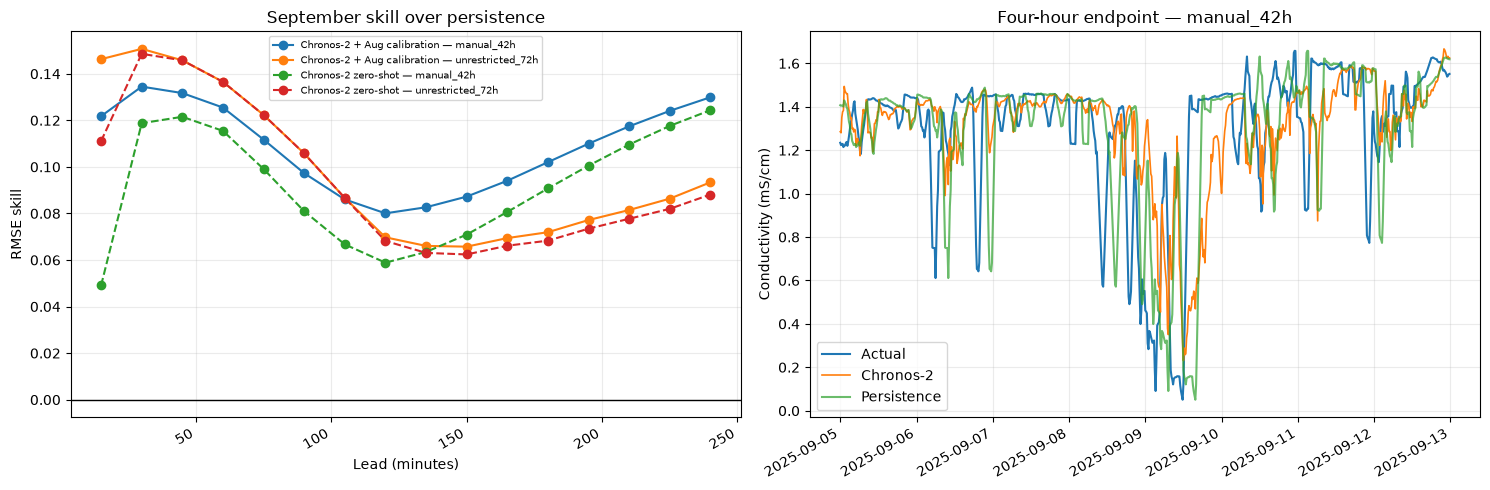

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (model_name, representation), group in horizon_results.groupby(["Model", "Representation"]):
    linestyle = "-" if "calibration" in model_name else "--"
    axes[0].plot(
        group["Lead minutes"], group["RMSE skill"],
        marker="o", linestyle=linestyle, label=f"{model_name} — {representation}",
    )
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="September skill over persistence", xlabel="Lead (minutes)", ylabel="RMSE skill")
axes[0].grid(alpha=.25)
axes[0].legend(fontsize=7)

# Select the visual representation using August calibration performance only.
validation_choice = pd.DataFrame(calibration_rows).sort_values("Validation RMSE").iloc[0]
best_representation = validation_choice["Representation"]
week = endpoint_predictions[("Chronos-2 + Aug calibration", best_representation)].loc["2025-09-05":"2025-09-12"]
axes[1].plot(week.index, week["Actual"], label="Actual", linewidth=1.5)
axes[1].plot(week.index, week["Prediction"], label="Chronos-2", linewidth=1.2)
axes[1].plot(week.index, week["Persistence"], label="Persistence", alpha=.7)
axes[1].set(title=f"Four-hour endpoint — {best_representation}", ylabel="Conductivity (mS/cm)")
axes[1].grid(alpha=.25)
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Reproducible conclusion

In [8]:
for representation in datasets:
    row = results[
        (results["Model"] == "Chronos-2 + Aug calibration")
        & (results["Representation"] == representation)
        & (results["Scope"] == "all horizons")
    ].iloc[0]
    raw = results[
        (results["Model"] == "Chronos-2 zero-shot")
        & (results["Representation"] == representation)
        & (results["Scope"] == "all horizons")
    ].iloc[0]
    print(
        f"{representation}: raw zero-shot RMSE={raw['RMSE']:.5f} "
        f"(skill {raw['RMSE skill']:.3f}); calibrated RMSE={row['RMSE']:.5f} "
        f"(skill {row['RMSE skill']:.3f})."
    )

best = results[
    (results["Model"] == "Chronos-2 + Aug calibration")
    & (results["Scope"] == "all horizons")
].sort_values("RMSE").iloc[0]
print(
    f"\nBest Chronos-2 representation: {best['Representation']} "
    f"with RMSE={best['RMSE']:.5f} and skill={best['RMSE skill']:.3f}."
)

unrestricted_72h: raw zero-shot RMSE=0.20608 (skill 0.081); calibrated RMSE=0.20541 (skill 0.084).
manual_42h: raw zero-shot RMSE=0.20372 (skill 0.092); calibrated RMSE=0.20085 (skill 0.105).

Best Chronos-2 representation: manual_42h with RMSE=0.20085 and skill=0.105.
